# 13. Сравнение Euclidean и Cosine как мер экономической близости

На этой контрольной проверке сравниваем две геометрические меры при одинаковых остальных настройках сети: `k = 10`, RBF-веса, Louvain и один набор значений `resolution`.

Цель - проверить, насколько вывод зависит от самого правила определения экономической близости.

In [57]:
import pandas as pd
import numpy as np
import networkx as nx

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score
)
from sklearn.metrics.pairwise import cosine_distances

from s_dbw import S_Dbw

print("Библиотеки для сравнения методов загружены.")

Библиотеки для сравнения методов загружены.


## 1. Загрузка признаков декабря 2024

Обе сети строятся на одном и том же наборе муниципалитетов и пяти экономических долях.

In [58]:
features_dec = pd.read_parquet(
    "../data/processed/features_2024_12.parquet"
)

feature_cols = [
    "food_share",
    "health_share",
    "marketplaces_share",
    "catering_share",
    "transport_share"
]

X_dec = features_dec[feature_cols].to_numpy()

print("Размер X:", X_dec.shape)

Размер X: (2103, 5)


## 2. Cosine-сеть с глобальным sigma

Для честного controlled comparison используем одну глобальную `sigma`, рассчитанную как медиану расстояний до k ближайших соседей по всей выборке. Это позволяет менять именно метрику расстояния, не добавляя одновременно дополнительную локальную нормализацию.

In [59]:
from sklearn.metrics.pairwise import cosine_distances

cosine_dist = cosine_distances(X_dec)

K_NEIGHBORS = 10

directed_neighbor_distances = []

for i in range(len(X_dec)):
    distances_i = cosine_dist[i].copy()
    distances_i[i] = np.inf
    nearest_idx = np.argsort(distances_i)[:K_NEIGHBORS]
    directed_neighbor_distances.extend(
        distances_i[nearest_idx]
    )

sigma_cosine = float(
    np.median(directed_neighbor_distances)
)

print("Global cosine sigma:", sigma_cosine)

cosine_edges = []

for i in range(len(X_dec)):
    distances_i = cosine_dist[i].copy()
    distances_i[i] = np.inf
    nearest_idx = np.argsort(distances_i)[:K_NEIGHBORS]

    for j in nearest_idx:
        d = distances_i[j]
        weight = np.exp(-d / sigma_cosine)
        cosine_edges.append(
            (
                int(features_dec.iloc[i]["territory_id"]),
                int(features_dec.iloc[j]["territory_id"]),
                float(weight)
            )
        )

cosine_edges = pd.DataFrame(
    cosine_edges,
    columns=["source", "target", "weight"]
)

print("Directed cosine edges:", len(cosine_edges))
print(cosine_edges.head())


Global cosine sigma: 0.0001293461780194627
Directed cosine edges: 21030
   source  target    weight
0       1    2597  0.215681
1       1     819  0.065635
2       1    1695  0.044334
3       1     812  0.028086
4       1    1453  0.022854


## 3. Симметризация и построение графа

Объединяем направленные kNN-связи и получаем неориентированный взвешенный граф, аналогичный Euclidean-сети.

In [60]:
cosine_edges_rev = cosine_edges.rename(
    columns={
        "source": "target",
        "target": "source"
    }
)

cosine_pairs = pd.concat(
    [cosine_edges, cosine_edges_rev],
    ignore_index=True
)

cosine_edges_undirected = (
    cosine_pairs
    .groupby(["source", "target"], as_index=False)["weight"]
    .mean()
)

G_cosine = nx.Graph()

G_cosine.add_nodes_from(
    features_dec["territory_id"].astype(int)
)

for row in cosine_edges_undirected.itertuples(index=False):
    G_cosine.add_edge(
        int(row.source),
        int(row.target),
        weight=float(row.weight)
    )

print("Cosine nodes:", G_cosine.number_of_nodes())
print("Cosine edges:", G_cosine.number_of_edges())
print(
    "Connected components:",
    nx.number_connected_components(G_cosine)
)

Cosine nodes: 2103
Cosine edges: 13798
Connected components: 1


## 4. Общий набор resolution

Обе меры сравниваются на одних и тех же шести значениях масштаба Louvain.

In [61]:
resolutions = [0.50, 0.75, 1.00, 1.25, 1.50, 2.00]

print("Resolution:", resolutions)

Resolution: [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]


## 5. Оценка cosine-сети

Для каждой настройки рассчитываем modularity, Silhouette, Calinski-Harabasz и S_Dbw.

In [62]:
cosine_comparison_results = []

for resolution in resolutions:
    communities = nx.community.louvain_communities(
        G_cosine,
        weight="weight",
        resolution=resolution,
        seed=42
    )

    partition = {}

    for cluster_id, community in enumerate(communities):
        for node in community:
            partition[node] = cluster_id

    labels = np.array([
        partition[int(territory_id)]
        for territory_id in features_dec["territory_id"]
    ])

    n_clusters = len(communities)

    modularity = nx.community.modularity(
        G_cosine,
        communities,
        weight="weight"
    )

    silhouette = silhouette_score(
        X_dec,
        labels,
        metric="euclidean"
    )

    calinski = calinski_harabasz_score(
        X_dec,
        labels
    )

    s_dbw = S_Dbw(
        X_dec,
        labels,
        method="Tong",
        alg_noise="bind",
        centr="mean",
        nearest_centr=True,
        metric="euclidean"
    )

    cosine_comparison_results.append({
        "method": "Cosine",
        "resolution": resolution,
        "n_clusters": n_clusters,
        "modularity": modularity,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "s_dbw": s_dbw
    })

cosine_comparison_df = pd.DataFrame(
    cosine_comparison_results
)

cosine_comparison_df.round(6)

,method,resolution,n_clusters,modularity,silhouette,calinski_harabasz,s_dbw
0,Cosine,0.50,20,0.799881,0.147004,642.606641,0.362762
1,Cosine,0.75,22,0.809789,0.159070,694.609142,0.344895
2,Cosine,1.00,27,0.812946,0.150324,677.182951,0.310685
3,Cosine,1.25,30,0.812854,0.155532,698.218507,0.302230
4,Cosine,1.50,33,0.808789,0.136176,684.233570,0.290254
5,Cosine,2.00,36,0.804581,0.147690,677.200117,0.288192


## 6. Добавление Euclidean-результатов

Подгружаем контрольные результаты из `12_icvi_evaluation`, чтобы сравнение строилось на одинаковом наборе метрик.

In [63]:
euclidean_comparison_df = pd.read_csv(
    "../data/processed/icvi_results_dec2024.csv"
)

euclidean_comparison_df = euclidean_comparison_df[
    [
        "resolution",
        "n_clusters",
        "modularity",
        "silhouette",
        "calinski_harabasz",
        "s_dbw"
    ]
].copy()

euclidean_comparison_df["method"] = "Euclidean"

cosine_final_df = cosine_comparison_df[
    [
        "method",
        "resolution",
        "n_clusters",
        "modularity",
        "silhouette",
        "calinski_harabasz",
        "s_dbw"
    ]
].copy()

method_comparison = pd.concat(
    [
        euclidean_comparison_df,
        cosine_final_df
    ],
    ignore_index=True
)

method_comparison = method_comparison.sort_values(
    ["resolution", "method"]
).reset_index(drop=True)

method_comparison.round(6)

,resolution,n_clusters,modularity,silhouette,calinski_harabasz,s_dbw,method
0,0.50,20,0.799881,0.147004,642.606641,0.362762,Cosine
1,0.50,11,0.799149,0.178519,877.296293,0.409699,Euclidean
2,0.75,22,0.809789,0.159070,694.609142,0.344895,Cosine
3,0.75,15,0.811850,0.191845,892.947191,0.368383,Euclidean
4,1.00,27,0.812946,0.150324,677.182951,0.310685,Cosine
5,1.00,17,0.814024,0.170096,852.564817,0.347601,Euclidean
6,1.25,30,0.812854,0.155532,698.218507,0.302230,Cosine
7,1.25,20,0.814475,0.163593,879.100115,0.321043,Euclidean
8,1.50,33,0.808789,0.136176,684.233570,0.290254,Cosine
9,1.50,19,0.813972,0.178424,914.598833,0.342515,Euclidean


## 7. Разности между методами

Вычисляем Euclidean minus Cosine для каждой метрики. Знак разности интерпретируем с учетом направления оптимальности индекса.

In [64]:
comparison_delta = (
    method_comparison
    .pivot(
        index="resolution",
        columns="method",
        values=[
            "n_clusters",
            "modularity",
            "silhouette",
            "calinski_harabasz",
            "s_dbw"
        ]
    )
)

comparison_delta

n_clusters           modularity           silhouette            \
method         Cosine Euclidean     Cosine Euclidean     Cosine Euclidean   
resolution                                                                  
0.50             20.0      11.0   0.799881  0.799149   0.147004  0.178519   
0.75             22.0      15.0   0.809789  0.811850   0.159070  0.191845   
1.00             27.0      17.0   0.812946  0.814024   0.150324  0.170096   
1.25             30.0      20.0   0.812854  0.814475   0.155532  0.163593   
1.50             33.0      19.0   0.808789  0.813972   0.136176  0.178424   
2.00             36.0      29.0   0.804581  0.799360   0.147690  0.114000   

           calinski_harabasz                 s_dbw            
method                Cosine   Euclidean    Cosine Euclidean  
resolution                                                    
0.50              642.606641  877.296293  0.362762  0.409699  
0.75              694.609142  892.947191  0.344895  0.368383  
1.00              677.182951  852.564817  0.310685  0.347601  
1.25              698.218507  879.100115  0.302230  0.321043  
1.50              684.233570  914.598833  0.290254  0.342515  
2.00              677.200117  623.715928  0.288192  0.281018

## 8. Полная таблица sensitivity analysis

Фиксируем K, modularity и все атрибутивные индексы для обеих мер расстояния.

In [65]:
method_summary = method_comparison[
    [
        "method",
        "resolution",
        "n_clusters",
        "modularity",
        "silhouette",
        "calinski_harabasz",
        "s_dbw"
    ]
].copy()

method_summary.to_csv(
    "../data/processed/method_comparison_full.csv",
    index=False
)

print("Таблица сравнения сохранена:")
print("../data/processed/method_comparison_full.csv")

method_summary.round(6)

Таблица сравнения сохранена:
../data/processed/method_comparison_full.csv


,method,resolution,n_clusters,modularity,silhouette,calinski_harabasz,s_dbw
0,Cosine,0.50,20,0.799881,0.147004,642.606641,0.362762
1,Euclidean,0.50,11,0.799149,0.178519,877.296293,0.409699
2,Cosine,0.75,22,0.809789,0.159070,694.609142,0.344895
3,Euclidean,0.75,15,0.811850,0.191845,892.947191,0.368383
4,Cosine,1.00,27,0.812946,0.150324,677.182951,0.310685
5,Euclidean,1.00,17,0.814024,0.170096,852.564817,0.347601
6,Cosine,1.25,30,0.812854,0.155532,698.218507,0.302230
7,Euclidean,1.25,20,0.814475,0.163593,879.100115,0.321043
8,Cosine,1.50,33,0.808789,0.136176,684.233570,0.290254
9,Euclidean,1.50,19,0.813972,0.178424,914.598833,0.342515


## 9. Сводка разностей

Таблица показывает, как меняется качество при переходе от cosine к Euclidean.

In [66]:
comparison_wide = method_comparison.pivot(
    index="resolution",
    columns="method",
    values=[
        "n_clusters",
        "modularity",
        "silhouette",
        "calinski_harabasz",
        "s_dbw"
    ]
)

delta_df = pd.DataFrame(index=comparison_wide.index)

delta_df["delta_clusters"] = (
    comparison_wide["n_clusters"]["Euclidean"]
    - comparison_wide["n_clusters"]["Cosine"]
)

delta_df["delta_modularity"] = (
    comparison_wide["modularity"]["Euclidean"]
    - comparison_wide["modularity"]["Cosine"]
)

delta_df["delta_silhouette"] = (
    comparison_wide["silhouette"]["Euclidean"]
    - comparison_wide["silhouette"]["Cosine"]
)

delta_df["delta_calinski_harabasz"] = (
    comparison_wide["calinski_harabasz"]["Euclidean"]
    - comparison_wide["calinski_harabasz"]["Cosine"]
)

delta_df["delta_s_dbw"] = (
    comparison_wide["s_dbw"]["Euclidean"]
    - comparison_wide["s_dbw"]["Cosine"]
)

delta_df.round(6)

,delta_clusters,delta_modularity,delta_silhouette,delta_calinski_harabasz,delta_s_dbw
resolution,,,,,
0.50,-9.0,-0.000731,0.031515,234.689652,0.046937
0.75,-7.0,0.002062,0.032775,198.338049,0.023488
1.00,-10.0,0.001077,0.019772,175.381866,0.036916
1.25,-10.0,0.001622,0.008061,180.881608,0.018813
1.50,-14.0,0.005183,0.042248,230.365263,0.052261
2.00,-7.0,-0.005221,-0.033689,-53.484189,-0.007174


In [67]:
import matplotlib.pyplot as plt

print("Matplotlib загружен.")

Matplotlib загружен.


## 10. Визуальное сравнение методов

Графики показывают изменение ключевых метрик при разных значениях `resolution`.

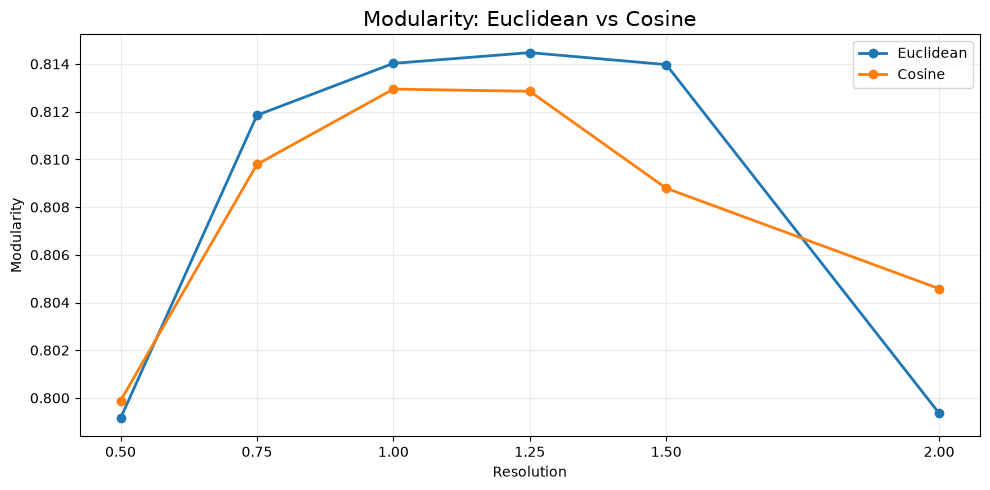

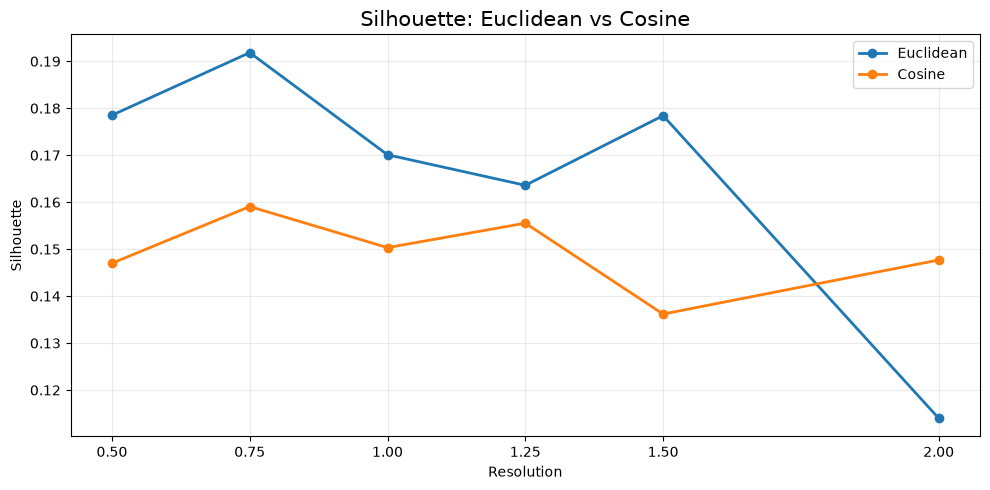

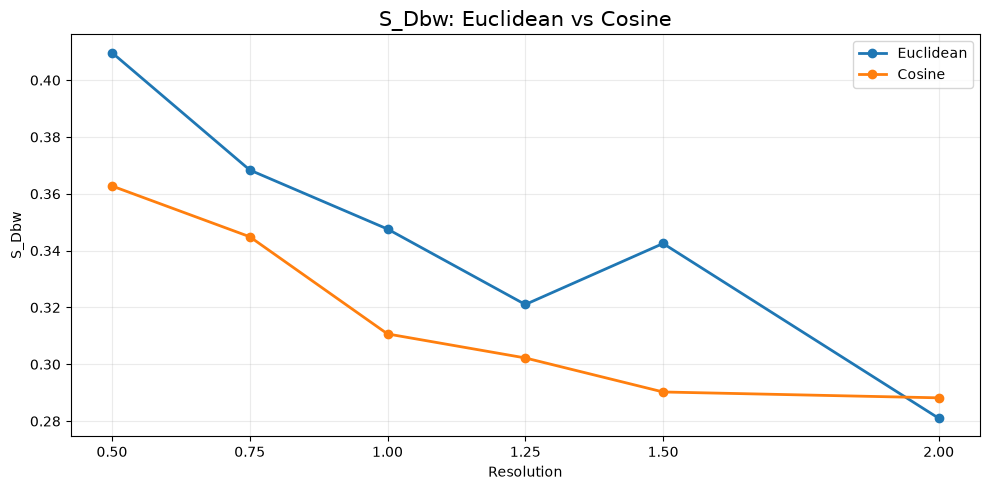

In [68]:
metrics = [
    ("modularity", "Modularity"),
    ("silhouette", "Silhouette"),
    ("s_dbw", "S_Dbw")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 5))

    for method in ["Euclidean", "Cosine"]:
        subset = method_comparison[
            method_comparison["method"] == method
        ]

        plt.plot(
            subset["resolution"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=method
        )

    plt.title(
        f"{title}: Euclidean vs Cosine",
        fontsize=15
    )

    plt.xlabel("Resolution")
    plt.ylabel(title)

    plt.xticks(resolutions)
    plt.legend()
    plt.grid(alpha=0.25)

    plt.tight_layout()

    plt.savefig(
        f"../outputs/figures/comparison_{metric}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 11. Сохранение результатов сравнения

Сохраняем полную таблицу и таблицу разностей для отчета и презентации.

In [69]:
method_comparison.to_csv(
    "../data/processed/method_comparison_full.csv",
    index=False
)

delta_df.to_csv(
    "../data/processed/method_comparison_delta.csv"
)

print("Результаты сравнения методов сохранены.")

Результаты сравнения методов сохранены.


## 12. Компактная таблица для конкурсной презентации

Сводим результаты в одну таблицу, чтобы на защите было видно одновременно K и четыре ключевых показателя качества.

In [70]:
metrics = [
    "modularity",
    "silhouette",
    "calinski_harabasz",
    "s_dbw"
]

rows = []

for resolution in resolutions:
    eu = method_comparison[
        (method_comparison["method"] == "Euclidean") &
        (method_comparison["resolution"] == resolution)
    ].iloc[0]

    co = method_comparison[
        (method_comparison["method"] == "Cosine") &
        (method_comparison["resolution"] == resolution)
    ].iloc[0]

    eu_wins = sum([
        eu["modularity"] > co["modularity"],
        eu["silhouette"] > co["silhouette"],
        eu["calinski_harabasz"] > co["calinski_harabasz"],
        eu["s_dbw"] < co["s_dbw"]
    ])

    rows.append({
        "Resolution": resolution,
        "K (Euclidean)": int(eu["n_clusters"]),
        "K (Cosine)": int(co["n_clusters"]),

        "Modularity\nE / C":
            f"{eu['modularity']:.4f} / {co['modularity']:.4f}",

        "Silhouette\nE / C":
            f"{eu['silhouette']:.4f} / {co['silhouette']:.4f}",

        "CH\nE / C":
            f"{eu['calinski_harabasz']:.1f} / {co['calinski_harabasz']:.1f}",

        "S_Dbw\nE / C":
            f"{eu['s_dbw']:.4f} / {co['s_dbw']:.4f}",

        "Показателей,\nгде E лучше":
            f"{eu_wins}/4"
    })

competition_table = pd.DataFrame(rows)

competition_table

,Resolution,K (Euclidean),K (Cosine),Modularity\nE / C,Silhouette\nE / C,CH\nE / C,S_Dbw\nE / C,"Показателей,\nгде E лучше"
0,0.50,11,20,0.7991 / 0.7999,0.1785 / 0.1470,877.3 / 642.6,0.4097 / 0.3628,2/4
1,0.75,15,22,0.8119 / 0.8098,0.1918 / 0.1591,892.9 / 694.6,0.3684 / 0.3449,3/4
2,1.00,17,27,0.8140 / 0.8129,0.1701 / 0.1503,852.6 / 677.2,0.3476 / 0.3107,3/4
3,1.25,20,30,0.8145 / 0.8129,0.1636 / 0.1555,879.1 / 698.2,0.3210 / 0.3022,3/4
4,1.50,19,33,0.8140 / 0.8088,0.1784 / 0.1362,914.6 / 684.2,0.3425 / 0.2903,3/4
5,2.00,29,36,0.7994 / 0.8046,0.1140 / 0.1477,623.7 / 677.2,0.2810 / 0.2882,1/4


## 13. Визуальная версия конкурсной таблицы

Сохраняем компактный рисунок, пригодный для слайда презентации.

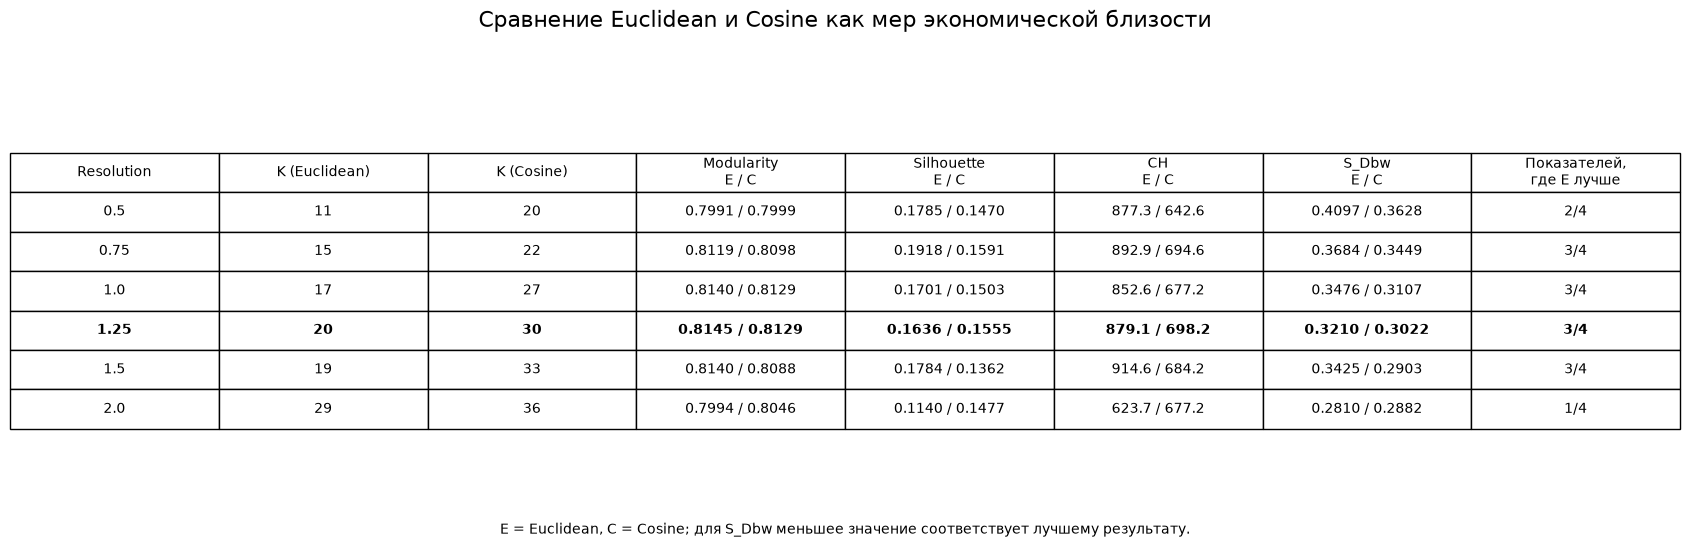

In [71]:
fig, ax = plt.subplots(
    figsize=(17, 5.5)
)

ax.axis("off")

table = ax.table(
    cellText=competition_table.values,
    colLabels=competition_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.1)

ax.set_title(
    "Сравнение Euclidean и Cosine как мер экономической близости",
    fontsize=16,
    pad=18
)

target_row = None

for (row, col), cell in table.get_celld().items():
    if cell.get_text().get_text() == "1.25":
        target_row = row
        break

if target_row is not None:
    for (row, col), cell in table.get_celld().items():
        if row == target_row:
            cell.set_text_props(weight="bold")

fig.text(
    0.5,
    0.02,
    "E = Euclidean, C = Cosine; для S_Dbw меньшее значение соответствует лучшему результату.",
    ha="center",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/method_comparison_competition_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Статус sensitivity analysis

После изменения cosine-сети этот ноутбук необходимо выполнить целиком заново. Старые cosine-результаты в сохраненных outputs не следует интерпретировать как актуальные, пока ноутбук не пересчитан с глобальной `sigma`.